In [ ]:
# Cell 1: Install all dependencies
!pip install pyarrow pandas numpy rasterio requests scikit-learn matplotlib scipy torch -q
print('✓ All packages installed')

✓ All packages installed


In [ ]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/cholera_pinn_data'
os.makedirs(DRIVE_DIR, exist_ok=True)

print(f'✓ Drive mounted')
print(f'✓ Output folder ready: {DRIVE_DIR}')

Mounted at /content/drive
✓ Drive mounted
✓ Output folder ready: /content/drive/MyDrive/cholera_pinn_data


In [ ]:
# Cell 3: Upload zip file and extract
from google.colab import files
import zipfile
import os

EXTRACT = '/content/cholera_data/'
os.makedirs(EXTRACT, exist_ok=True)

# Upload the zip file
print('Please upload osfstorage-archive.zip ...')
uploaded = files.upload()

# Extract
zip_name = list(uploaded.keys())[0]
print(f'\nExtracting {zip_name}...')
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(EXTRACT)

print('✓ Extracted files:')
for f in os.listdir(EXTRACT):
    print(f'  {f}')

Please upload osfstorage-archive.zip ...


Saving osfstorage-archive.zip to osfstorage-archive (1).zip

Extracting osfstorage-archive (1).zip...
✓ Extracted files:
  Public_surveillance_dataset.rds
  Location_masked_surveillance_dataset.rds
  Public_outbreak_dataset.rds
  Location_masked_outbreak_dataset.rds
  Public_outbreak_dataset.parquet
  Location_masked_outbreak_dataset.parquet
  data_dictionaries.xlsx
  Location_masked_surveillance_dataset.parquet
  Public_surveillance_shapefiles.rds
  Public_surveillance_shapefiles.gpkg
  Public_surveillance_dataset.parquet


In [ ]:
# Cell 4: Load parquet and extract South Sudan data
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_parquet(f'{EXTRACT}Public_surveillance_dataset.parquet')
df['TL'] = pd.to_datetime(df['TL'])
df['TR'] = pd.to_datetime(df['TR'])
df['iso'] = df['location_name'].str.extract(r'(?:AFR|EMR)::([A-Z]{3})')

print(f'✓ Dataset loaded: {df.shape}')
print(f'  Columns: {df.columns.tolist()}')
print()

# Extract South Sudan country-level non-phantom data
ssd = df[
    (df['iso'] == 'SSD') &
    (df['spatial_scale'] == 'country') &
    (~df['phantom'])
].sort_values('TL').reset_index(drop=True)

# Date filter
ssd = ssd[
    (ssd['TL'] >= '2016-06-06') &
    (ssd['TL'] <= '2017-12-25')
].reset_index(drop=True)

print(f'=== SOUTH SUDAN (SSD) ===')
print(f'  Weeks      : {len(ssd)}')
print(f'  Date range : {ssd["TL"].min().date()} to {ssd["TL"].max().date()}')
print(f'  Cases NaN  : {ssd["sCh"].isna().sum()}')
print(f'  Deaths NaN : {ssd["deaths"].isna().sum()}')
print(f'  Zero weeks : {(ssd["sCh"]==0).sum()}')
print(f'  Cases mean : {ssd["sCh"].mean():.0f}/week')
print(f'  Cases max  : {ssd["sCh"].max():.0f}/week')
print(f'  Deaths max : {ssd["deaths"].max():.0f}/week')

✓ Dataset loaded: (336380, 17)
  Columns: ['location_name', 'TL', 'TR', 'sCh', 'cCh', 'deaths', 'epiweek', 'start_weekday', 'spatial_scale', 'composite_loc', 'date_range', 'phantom', 'observation_collection_id', 'original_location_name', 'location_period_id', 'pop', 'iso']

=== SOUTH SUDAN (SSD) ===
  Weeks      : 82
  Date range : 2016-06-06 to 2017-12-25
  Cases NaN  : 0
  Deaths NaN : 0
  Zero weeks : 5
  Cases mean : 231/week
  Cases max  : 1220/week
  Deaths max : 827/week


In [ ]:
# Cell 5: Normalise and prepare South Sudan data
# No rainfall used in the main pipeline yet — we'll verify this properly in the
# new rainfall cell later rather than assuming it, per your supervisor's note

cases_raw  = ssd['sCh'].values.astype(float)
deaths_raw = ssd['deaths'].values.astype(float)
pop        = float(ssd['pop'].iloc[0])

# Normalisation factors
s_cases  = float(np.nanmax(cases_raw))
s_deaths = float(np.nanmax(deaths_raw))

# Normalised values
cases_norm  = np.clip(cases_raw  / s_cases,  0, None)
deaths_norm = np.clip(deaths_raw / s_deaths, 0, None)

# Time index
t_raw = np.arange(len(ssd)).astype(float)

print('=== SOUTH SUDAN — NORMALISED DATA ===')
print(f'  Population   : {pop:,.0f}')
print(f'  cases_max    : {s_cases:.0f}')
print(f'  deaths_max   : {s_deaths:.0f}')
print(f'  Cases NaN    : {np.isnan(cases_norm).sum()}')
print(f'  Deaths NaN   : {np.isnan(deaths_norm).sum()}')
print(f'  Cases range  : {cases_norm.min():.4f} – {cases_norm.max():.4f}')
print(f'  Deaths range : {deaths_norm.min():.4f} – {deaths_norm.max():.4f}')
print()

# Yearly breakdown
ssd['year'] = ssd['TL'].dt.year
for yr in sorted(ssd['year'].unique()):
    sub = ssd[ssd['year']==yr]
    print(f'  {yr}: {len(sub)} weeks | '
          f'cases mean={sub["sCh"].mean():.0f} '
          f'max={sub["sCh"].max():.0f} | '
          f'deaths mean={sub["deaths"].mean():.0f} '
          f'max={sub["deaths"].max():.0f}')

# CFR sanity check
implied_cfr = (ssd['deaths'] / ssd['sCh'].replace(0, np.nan)).mean() * 100
print(f'\n  Implied mean weekly CFR: {implied_cfr:.1f}%  (plausible cholera CFR is <2% with treatment)')

=== SOUTH SUDAN — NORMALISED DATA ===
  Population   : 11,085,425
  cases_max    : 1220
  deaths_max   : 827
  Cases NaN    : 0
  Deaths NaN   : 0
  Cases range  : 0.0000 – 1.0000
  Deaths range : 0.0000 – 1.0000

  2016: 30 weeks | cases mean=172 max=1119 | deaths mean=82 max=145
  2017: 52 weeks | cases mean=265 max=1220 | deaths mean=171 max=827

  Implied mean weekly CFR: 73.7%  (plausible cholera CFR is <2% with treatment)


In [ ]:
# Cell 6: Setup baseline variables
import torch
import torch.nn as nn
import numpy as np
import scipy.io as sio
from sklearn.metrics import mean_absolute_error as mae

# ── Settings ───────────────────────────────────────────────────
WINDOW     = 7
ITER       = 2000
HIDDEN     = 50
WEEK_MAX   = 82
TRAIN_FROM = 0
PRED_FROM  = 20
device     = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Features ───────────────────────────────────────────────────
# For South Sudan: cases + deaths (NO rainfall — not useful)
features   = np.stack([cases_norm, deaths_norm], axis=1)
cases_ref  = cases_norm.tolist()
deaths_ref = deaths_norm.tolist()

print(f'✓ Baseline setup ready')
print(f'  Device     : {device}')
print(f'  Features   : {features.shape}  (cases + deaths)')
print(f'  WEEK_MAX   : {WEEK_MAX}')
print(f'  PRED_FROM  : {PRED_FROM}')
print(f'  Windows    : {WEEK_MAX - 4 - PRED_FROM + 1}')
print()

# ── Shared utilities ───────────────────────────────────────────
def make_windows(data, window, start, end):
    X, y = [], []
    for t in range(start, end):
        if t - window < 0:
            continue
        X.append(data[t - window:t])
        y.append(data[t, 0:2])  # predict BOTH cases and deaths
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32))

def compute_mase(refs, preds, horizon):
    h = horizon
    valid = [(p,r,cases_ref[i-h])
             for i,(p,r) in enumerate(zip(preds,refs))
             if p != 0 and i >= h]
    if not valid:
        return float('nan')
    p_arr, r_arr, n_arr = zip(*valid)
    mae_m = mae(r_arr, p_arr)
    mae_n = mae(r_arr, n_arr)
    return mae_m / mae_n if mae_n > 0 else float('nan')

print('✓ Utilities ready')
print()
print('Note: We predict BOTH cases and deaths for South Sudan')

✓ Baseline setup ready
  Device     : cuda
  Features   : (82, 2)  (cases + deaths)
  WEEK_MAX   : 82
  PRED_FROM  : 20
  Windows    : 59

✓ Utilities ready

Note: We predict BOTH cases and deaths for South Sudan


In [ ]:
# Cell 7: RNN Baseline — South Sudan (cases + deaths)

class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(2, HIDDEN, 2, batch_first=True)
        self.fc  = nn.Linear(HIDDEN, 2)  # predict cases + deaths
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def train_rnn(features, train_start, train_end):
    model   = RNNModel().to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    X, y    = make_windows(features, WINDOW, train_start, train_end)
    if len(X) == 0:
        return model
    X_t = torch.tensor(X).to(device)
    y_t = torch.tensor(y).to(device)
    min_loss, best_state = 1e10, None
    for it in range(ITER):
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if loss.item() < min_loss:
            min_loss   = loss.item()
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model

def predict_rnn(model, features, test_start):
    model.eval()
    preds   = []
    current = features[test_start - WINDOW:test_start].copy()
    with torch.no_grad():
        for h in range(4):
            X    = torch.tensor(current[-WINDOW:].reshape(1, WINDOW, 2),
                                dtype=torch.float32).to(device)
            pred = model(X).cpu().numpy().flatten()
            pred = np.clip(pred, 0, None)
            preds.append(pred)
            new_row = np.array([pred[0], pred[1]])
            current = np.vstack([current, new_row])
    return preds

# ── Rolling window ─────────────────────────────────────────────
rnn_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
rnn_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training RNN...')
for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1
    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')
    model = train_rnn(features, TRAIN_FROM, train_end)
    preds = predict_rnn(model, features, test_start)
    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            rnn_cases_pred[h][idx]  = float(preds[h][0])
            rnn_deaths_pred[h][idx] = float(preds[h][1])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== RNN MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      rnn_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      rnn_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

Training RNN...
  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== RNN MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.680✓     0.384✓
2-week        0.869✓     0.561✓
3-week        0.916✓     0.594✓
4-week        1.536✗     0.768✓


In [ ]:
# Cell 7: RNN Baseline — South Sudan (cases + deaths)
torch.manual_seed(42)
np.random.seed(42)

class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(2, HIDDEN, 2, batch_first=True)
        self.fc  = nn.Linear(HIDDEN, 2)  # predict cases + deaths
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def train_rnn(features, train_start, train_end):
    model   = RNNModel().to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    X, y    = make_windows(features, WINDOW, train_start, train_end)
    if len(X) == 0:
        return model
    X_t = torch.tensor(X).to(device)
    y_t = torch.tensor(y).to(device)
    min_loss, best_state = 1e10, None
    for it in range(ITER):
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if loss.item() < min_loss:
            min_loss   = loss.item()
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model

def predict_rnn(model, features, test_start):
    model.eval()
    preds   = []
    current = features[test_start - WINDOW:test_start].copy()
    with torch.no_grad():
        for h in range(4):
            X    = torch.tensor(current[-WINDOW:].reshape(1, WINDOW, 2),
                                dtype=torch.float32).to(device)
            pred = model(X).cpu().numpy().flatten()
            pred = np.clip(pred, 0, None)
            preds.append(pred)
            new_row = np.array([pred[0], pred[1]])
            current = np.vstack([current, new_row])
    return preds

# ── Rolling window ─────────────────────────────────────────────
rnn_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
rnn_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training RNN...')
for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1
    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')
    model = train_rnn(features, TRAIN_FROM, train_end)
    preds = predict_rnn(model, features, test_start)
    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            rnn_cases_pred[h][idx]  = float(preds[h][0])
            rnn_deaths_pred[h][idx] = float(preds[h][1])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== RNN MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      rnn_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      rnn_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

Training RNN...
  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== RNN MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.629✓     0.445✓
2-week        0.484✓     0.524✓
3-week        0.656✓     0.478✓
4-week        0.795✓     0.686✓


In [ ]:
# Cell 8: LSTM Baseline — South Sudan (cases + deaths)
torch.manual_seed(42)
np.random.seed(42)

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2, HIDDEN, 2, batch_first=True)
        self.fc   = nn.Linear(HIDDEN, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def train_lstm(features, train_start, train_end):
    model   = LSTMModel().to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    X, y    = make_windows(features, WINDOW, train_start, train_end)
    if len(X) == 0:
        return model
    X_t = torch.tensor(X).to(device)
    y_t = torch.tensor(y).to(device)
    min_loss, best_state = 1e10, None
    for it in range(ITER):
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if loss.item() < min_loss:
            min_loss   = loss.item()
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model

def predict_lstm(model, features, test_start):
    model.eval()
    preds   = []
    current = features[test_start - WINDOW:test_start].copy()
    with torch.no_grad():
        for h in range(4):
            X    = torch.tensor(current[-WINDOW:].reshape(1, WINDOW, 2),
                                dtype=torch.float32).to(device)
            pred = model(X).cpu().numpy().flatten()
            pred = np.clip(pred, 0, None)
            preds.append(pred)
            new_row = np.array([pred[0], pred[1]])
            current = np.vstack([current, new_row])
    return preds

# ── Rolling window ─────────────────────────────────────────────
lstm_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
lstm_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training LSTM...')
for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1
    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')
    model = train_lstm(features, TRAIN_FROM, train_end)
    preds = predict_lstm(model, features, test_start)
    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            lstm_cases_pred[h][idx]  = float(preds[h][0])
            lstm_deaths_pred[h][idx] = float(preds[h][1])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== LSTM MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      lstm_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      lstm_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

Training LSTM...
  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== LSTM MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.614✓     0.468✓
2-week        0.602✓     0.636✓
3-week        0.759✓     0.714✓
4-week        0.731✓     0.798✓


In [ ]:
# Cell 9: GRU Baseline — South Sudan (cases + deaths)
torch.manual_seed(42)
np.random.seed(42)

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(2, HIDDEN, 2, batch_first=True)
        self.fc  = nn.Linear(HIDDEN, 2)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

def train_gru(features, train_start, train_end):
    model   = GRUModel().to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    X, y    = make_windows(features, WINDOW, train_start, train_end)
    if len(X) == 0:
        return model
    X_t = torch.tensor(X).to(device)
    y_t = torch.tensor(y).to(device)
    min_loss, best_state = 1e10, None
    for it in range(ITER):
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if loss.item() < min_loss:
            min_loss   = loss.item()
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model

def predict_gru(model, features, test_start):
    model.eval()
    preds   = []
    current = features[test_start - WINDOW:test_start].copy()
    with torch.no_grad():
        for h in range(4):
            X    = torch.tensor(current[-WINDOW:].reshape(1, WINDOW, 2),
                                dtype=torch.float32).to(device)
            pred = model(X).cpu().numpy().flatten()
            pred = np.clip(pred, 0, None)
            preds.append(pred)
            new_row = np.array([pred[0], pred[1]])
            current = np.vstack([current, new_row])
    return preds

# ── Rolling window ─────────────────────────────────────────────
gru_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
gru_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training GRU...')
for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1
    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')
    model = train_gru(features, TRAIN_FROM, train_end)
    preds = predict_gru(model, features, test_start)
    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            gru_cases_pred[h][idx]  = float(preds[h][0])
            gru_deaths_pred[h][idx] = float(preds[h][1])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== GRU MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      gru_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      gru_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

Training GRU...
  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== GRU MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.784✓     0.391✓
2-week        0.583✓     0.589✓
3-week        0.951✓     0.677✓
4-week        1.180✗     0.760✓


In [ ]:
# Cell 10: Transformer Baseline — South Sudan (cases + deaths)
torch.manual_seed(42)
np.random.seed(42)

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(2, 64)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=4,
            dim_feedforward=128,
            dropout=0.0,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, 2)
        self.fc          = nn.Linear(64, 2)
    def forward(self, x):
        x = self.proj(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

def train_transformer(features, train_start, train_end):
    model   = TransformerModel().to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    X, y    = make_windows(features, WINDOW, train_start, train_end)
    if len(X) == 0:
        return model
    X_t = torch.tensor(X).to(device)
    y_t = torch.tensor(y).to(device)
    min_loss, best_state = 1e10, None
    for it in range(ITER):
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if loss.item() < min_loss:
            min_loss   = loss.item()
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model

def predict_transformer(model, features, test_start):
    model.eval()
    preds   = []
    current = features[test_start - WINDOW:test_start].copy()
    with torch.no_grad():
        for h in range(4):
            X    = torch.tensor(current[-WINDOW:].reshape(1, WINDOW, 2),
                                dtype=torch.float32).to(device)
            pred = model(X).cpu().numpy().flatten()
            pred = np.clip(pred, 0, None)
            preds.append(pred)
            new_row = np.array([pred[0], pred[1]])
            current = np.vstack([current, new_row])
    return preds

# ── Rolling window ─────────────────────────────────────────────
tf_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
tf_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training Transformer...')
for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1
    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')
    model = train_transformer(features, TRAIN_FROM, train_end)
    preds = predict_transformer(model, features, test_start)
    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            tf_cases_pred[h][idx]  = float(preds[h][0])
            tf_deaths_pred[h][idx] = float(preds[h][1])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== Transformer MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      tf_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      tf_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

Training Transformer...
  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== Transformer MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.423✓     0.377✓
2-week        0.528✓     0.394✓
3-week        0.878✓     0.479✓
4-week        0.709✓     0.719✓


In [ ]:
# Cell 11: Pure NN Baseline — South Sudan (cases + deaths)
torch.manual_seed(42)
np.random.seed(42)

class PureNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(WINDOW * 2, HIDDEN), nn.Tanh(),
            nn.Linear(HIDDEN, HIDDEN),     nn.Tanh(),
            nn.Linear(HIDDEN, 2)
        )
    def forward(self, x):
        return self.net(x)

def train_nn(features, train_start, train_end):
    model   = PureNN().to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    X, y    = make_windows(features, WINDOW, train_start, train_end)
    if len(X) == 0:
        return model
    X_t = torch.tensor(X).to(device)
    y_t = torch.tensor(y).to(device)
    X_t = X_t.view(X_t.shape[0], -1)
    min_loss, best_state = 1e10, None
    for it in range(ITER):
        pred = model(X_t)
        loss = loss_fn(pred, y_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if loss.item() < min_loss:
            min_loss   = loss.item()
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model

def predict_nn(model, features, test_start):
    model.eval()
    preds   = []
    current = features[test_start - WINDOW:test_start].copy()
    with torch.no_grad():
        for h in range(4):
            X    = torch.tensor(current[-WINDOW:].reshape(1, WINDOW, 2),
                                dtype=torch.float32).to(device)
            X    = X.view(1, -1)
            pred = model(X).cpu().numpy().flatten()
            pred = np.clip(pred, 0, None)
            preds.append(pred)
            new_row = np.array([pred[0], pred[1]])
            current = np.vstack([current, new_row])
    return preds

# ── Rolling window ─────────────────────────────────────────────
nn_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
nn_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training Pure NN...')
for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1
    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')
    model = train_nn(features, TRAIN_FROM, train_end)
    preds = predict_nn(model, features, test_start)
    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            nn_cases_pred[h][idx]  = float(preds[h][0])
            nn_deaths_pred[h][idx] = float(preds[h][1])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== Pure NN MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      nn_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      nn_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

Training Pure NN...
  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== Pure NN MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.739✓     0.582✓
2-week        0.857✓     0.676✓
3-week        1.165✗     0.828✓
4-week        1.188✗     1.003✗


In [ ]:
# Cell 12: PINN — Direct ODE rate as observable (no autograd derivative)
torch.manual_seed(42)
np.random.seed(42)

import torch
import torch.nn as nn
from torch.autograd import grad
import numpy as np
import os

class NN(nn.Module):
    def __init__(self, layers, output_transform=None):
        super().__init__()
        self.net = nn.ModuleList()
        self.output_transform = output_transform
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
    def forward(self, x):
        x = x / 82.0
        for layer in self.net[:-1]:
            x = torch.tanh(layer(x))
        x = self.net[-1](x)
        if self.output_transform:
            x = self.output_transform(x)
        return x

def compute_lhs(t, state_vars):
    derivs = []
    for u in state_vars:
        du = grad(u, t,
                  grad_outputs=torch.ones_like(u),
                  create_graph=True)[0]
        derivs.append(du)
    return torch.cat(derivs, dim=-1)

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
WEEK_MAX   = 82
PRED_FROM  = 20
TRAIN_FROM = 0
PINN_ITER  = 5000

N=1.0; gamma=1/1.5; delta=1/2.0; xi=0.5; kappa=1e6

def T(arr, requires_grad=False):
    return torch.tensor(arr, dtype=torch.float32,
                        requires_grad=requires_grad).to(device)

t_all     = T(np.arange(WEEK_MAX).reshape(-1,1).astype(float))
t_ode_all = T(np.arange(0, WEEK_MAX, 0.25).reshape(-1,1),
              requires_grad=True)
cases_T   = T(cases_norm.reshape(-1,1))
deaths_T  = T(deaths_norm.reshape(-1,1))

os.makedirs('./checkpoints', exist_ok=True)

pinn_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
pinn_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training PINN (South Sudan)...')
print()

for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1

    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')

    sl        = slice(TRAIN_FROM, train_end)
    t_train   = t_all[sl]
    t_ode     = t_ode_all[TRAIN_FROM*4:(test_start+4)*4+1]
    t_test    = t_all[test_start:test_start+4]
    cases_tr  = cases_T[sl]
    deaths_tr = deaths_T[sl]

    upper = NN([1,50,50,50,6], output_transform=torch.exp).to(device)
    lower = NN([1,50,50,50,2], output_transform=None).to(device)

    logit_pd = torch.tensor(
        float(np.log(0.02/0.98)),
        dtype=torch.float32,
        requires_grad=True, device=device
    )

    opt = torch.optim.Adam([
        {'params': list(upper.parameters()) +
                   list(lower.parameters()), 'lr': 1e-3},
        {'params': [logit_pd], 'lr': 5e-3},
    ], weight_decay=1e-5)

    I0 = max(float(cases_tr[0].item())*0.1, 1e-4)
    S0 = N - I0
    u0 = T([[S0, I0, 0.0, I0*0.5, 0.0, 0.0]])
    t0 = T([[float(TRAIN_FROM)]])

    min_loss = 1e10

    for it in range(PINN_ITER):
        p_d = 0.01 + 0.09 * torch.sigmoid(logit_pd)

        state  = upper(t_ode)
        S,I,R,B,Ir,Dr = torch.split(state, 1, dim=-1)

        cov    = lower(t_ode)
        beta_I = torch.exp(cov[:,0:1])
        beta_W = torch.exp(cov[:,1:2])

        foi    = beta_I*S*I/N + beta_W*S*B/(kappa+B)
        dS_rhs = -foi
        dI_rhs =  foi - gamma*I
        dR_rhs =  gamma*(1.0-p_d)*I
        dB_rhs =  xi*I - delta*B
        dIr_rhs=  gamma*(1.0-p_d)*I
        dDr_rhs=  gamma*p_d*I

        lhs    = compute_lhs(t_ode, [S,I,R,B,Ir,Dr])
        rhs    = torch.cat([dS_rhs,dI_rhs,dR_rhs,
                            dB_rhs,dIr_rhs,dDr_rhs], dim=-1)
        loss_ode = torch.mean((lhs - rhs)**2)

        state_t0  = upper(t0)
        loss_init = torch.mean((state_t0 - u0)**2)

        state_tr   = upper(t_train)
        S_tr,I_tr,R_tr,B_tr,Ir_tr,Dr_tr = torch.split(
            state_tr, 1, dim=-1)

        cov_tr   = lower(t_train)
        bI_tr    = torch.exp(cov_tr[:,0:1])
        bW_tr    = torch.exp(cov_tr[:,1:2])

        new_cases_rate  = gamma * (1.0 - p_d) * I_tr
        new_deaths_rate = gamma * p_d * I_tr

        loss_cases  = torch.mean((new_cases_rate  - cases_tr)**2)
        loss_deaths = torch.mean((new_deaths_rate - deaths_tr)**2)

        total_loss = (
            0.05 * loss_ode   +
            0.5  * loss_init  +
            1.0  * loss_cases +
            0.3  * loss_deaths
        )

        opt.zero_grad()
        total_loss.backward()
        opt.step()

        if total_loss.item() < min_loss:
            min_loss = total_loss.item()
            torch.save(upper.state_dict(),
                       './checkpoints/pinn_upper.pt')
            torch.save(lower.state_dict(),
                       './checkpoints/pinn_lower.pt')

    upper.load_state_dict(
        torch.load('./checkpoints/pinn_upper.pt'))
    lower.load_state_dict(
        torch.load('./checkpoints/pinn_lower.pt'))
    upper.eval()
    lower.eval()

    with torch.no_grad():
        state_test = upper(t_test)
        _,I_test,_,_,_,_ = torch.split(state_test, 1, dim=-1)

        p_d_final = 0.01 + 0.09 * torch.sigmoid(logit_pd)

        cases_pred  = (gamma*(1.0-p_d_final)*I_test).cpu().numpy().flatten()
        deaths_pred = (gamma*p_d_final*I_test).cpu().numpy().flatten()

        cases_pred  = np.clip(cases_pred,  0, None)
        deaths_pred = np.clip(deaths_pred, 0, None)

    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            pinn_cases_pred[h][idx]  = float(cases_pred[h])
            pinn_deaths_pred[h][idx] = float(deaths_pred[h])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== PINN MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      pinn_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      pinn_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

Training PINN (South Sudan)...

  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== PINN MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.355✓     0.678✓
2-week        0.389✓     0.674✓
3-week        0.448✓     0.637✓
4-week        0.464✓     0.643✓


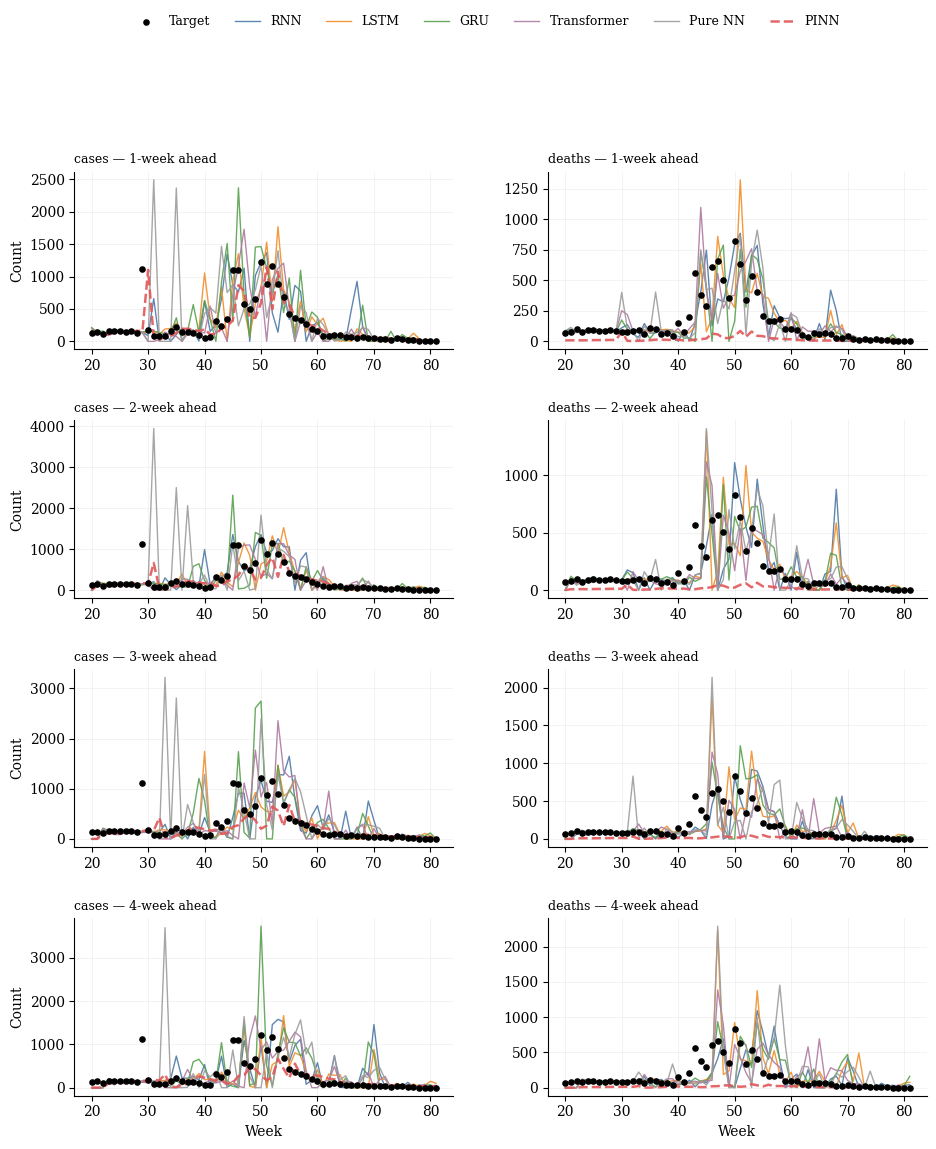

✓ Saved ssd_combined_comparison.pdf / .png


In [ ]:
# Cell 14: Combined comparison plot — South Sudan
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'grid.linewidth': 0.5,
})

models = {
    'RNN':         (rnn_cases_pred,  rnn_deaths_pred,  '#4E79A7'),
    'LSTM':        (lstm_cases_pred, lstm_deaths_pred, '#F28E2B'),
    'GRU':         (gru_cases_pred,  gru_deaths_pred,  '#59A14F'),
    'Transformer': (tf_cases_pred,   tf_deaths_pred,   '#B07AA1'),
    'Pure NN':     (nn_cases_pred,   nn_deaths_pred,   '#9C9C9C'),
    'PINN':        (pinn_cases_pred, pinn_deaths_pred, '#E15759'),
}

weeks = np.arange(WEEK_MAX)
eval_idx = np.arange(PRED_FROM, WEEK_MAX)

fig = plt.figure(figsize=(11, 12))
gs  = gridspec.GridSpec(4, 2, hspace=0.4, wspace=0.25)

for row, h in enumerate(range(1, 5)):
    for col, (target_name, raw_actual, scale) in enumerate([
        ('cases',  cases_raw,  s_cases),
        ('deaths', deaths_raw, s_deaths),
    ]):
        ax = fig.add_subplot(gs[row, col])

        ax.scatter(eval_idx, raw_actual[eval_idx], s=14, color='black',
                   zorder=5, label='Target' if (row==0 and col==0) else None)

        for name, (cases_p, deaths_p, color) in models.items():
            pred_arr = (cases_p if target_name == 'cases' else deaths_p)[h-1]
            pred_raw = np.array(pred_arr)[eval_idx] * scale
            ls = '--' if name == 'PINN' else '-'
            lw = 1.8 if name == 'PINN' else 1.0
            ax.plot(eval_idx, pred_raw, linestyle=ls, linewidth=lw,
                    color=color, alpha=0.9,
                    label=name if (row==0 and col==0) else None)

        ax.set_title(f'{target_name} — {h}-week ahead', loc='left', fontsize=9)
        if row == 3:
            ax.set_xlabel('Week')
        if col == 0:
            ax.set_ylabel('Count')

fig.legend(loc='upper center', ncol=7, bbox_to_anchor=(0.5, 1.02), fontsize=9, frameon=False)
plt.savefig('ssd_combined_comparison.pdf', bbox_inches='tight')
plt.savefig('ssd_combined_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved ssd_combined_comparison.pdf / .png')

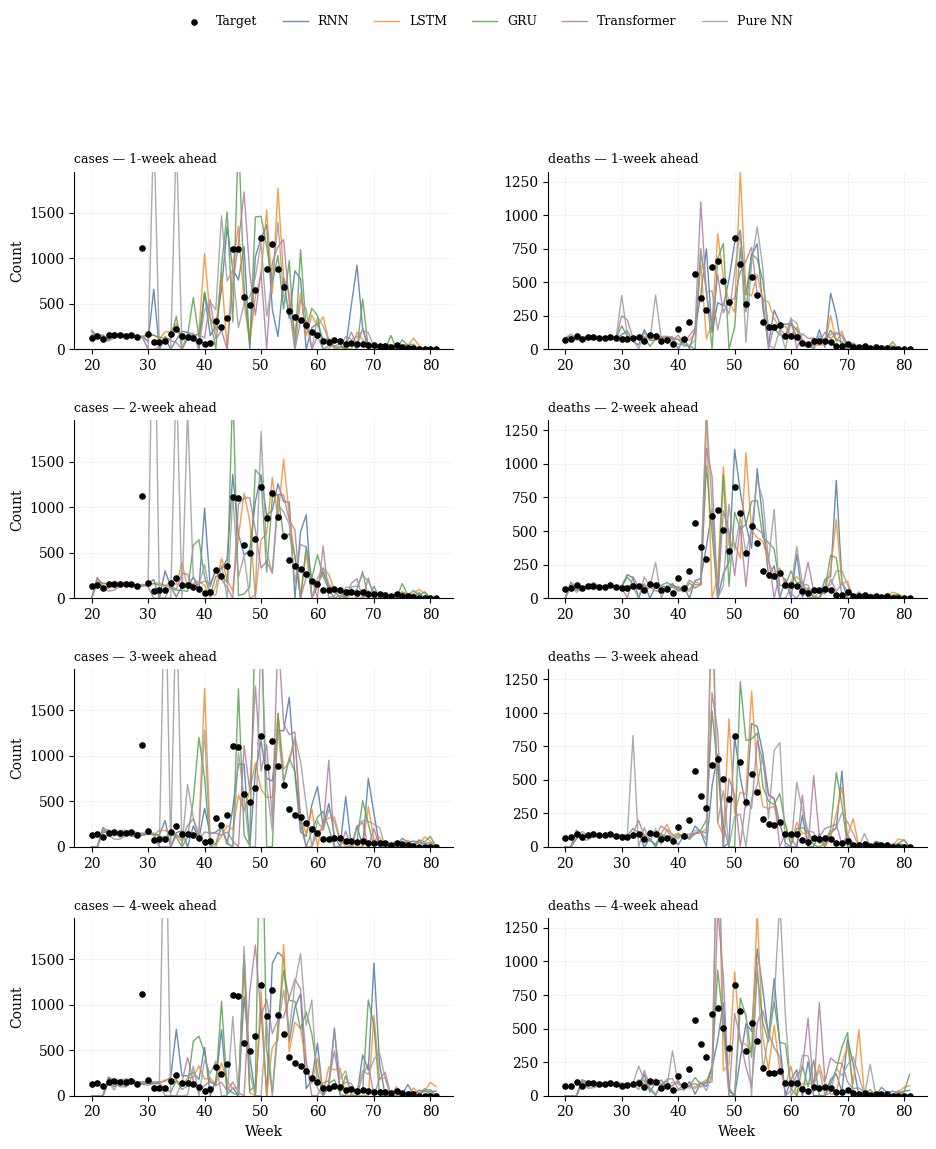

✓ Saved ssd_baselines_comparison.pdf / .png


In [ ]:
# Cell 14a: Baseline comparison plot (matches reference Fig. 6 style)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'grid.linewidth': 0.5,
})

baseline_models = {
    'RNN':         (rnn_cases_pred,  rnn_deaths_pred,  '#4E79A7'),
    'LSTM':        (lstm_cases_pred, lstm_deaths_pred, '#F28E2B'),
    'GRU':         (gru_cases_pred,  gru_deaths_pred,  '#59A14F'),
    'Transformer': (tf_cases_pred,   tf_deaths_pred,   '#B07AA1'),
    'Pure NN':     (nn_cases_pred,   nn_deaths_pred,   '#9C9C9C'),
}

eval_idx = np.arange(PRED_FROM, WEEK_MAX)

# Fixed y-limits per column, based on target range — matches how Qian's Fig. 6
# keeps a consistent scale down each column rather than autoscaling every panel
cases_ylim  = (0, cases_raw[eval_idx].max() * 1.6)
deaths_ylim = (0, deaths_raw[eval_idx].max() * 1.6)

fig = plt.figure(figsize=(11, 12))
gs  = gridspec.GridSpec(4, 2, hspace=0.4, wspace=0.25)

for row, h in enumerate(range(1, 5)):
    for col, (target_name, raw_actual, scale, ylim) in enumerate([
        ('cases',  cases_raw,  s_cases,  cases_ylim),
        ('deaths', deaths_raw, s_deaths, deaths_ylim),
    ]):
        ax = fig.add_subplot(gs[row, col])
        ax.scatter(eval_idx, raw_actual[eval_idx], s=14, color='black',
                   zorder=5, label='Target' if (row==0 and col==0) else None)

        for name, (cases_p, deaths_p, color) in baseline_models.items():
            pred_arr = (cases_p if target_name == 'cases' else deaths_p)[h-1]
            pred_raw = np.array(pred_arr)[eval_idx] * scale
            ax.plot(eval_idx, pred_raw, linewidth=1.0, color=color, alpha=0.85,
                    label=name if (row==0 and col==0) else None)

        ax.set_ylim(ylim)
        ax.set_title(f'{target_name} — {h}-week ahead', loc='left', fontsize=9)
        if row == 3: ax.set_xlabel('Week')
        if col == 0: ax.set_ylabel('Count')

fig.legend(loc='upper center', ncol=6, bbox_to_anchor=(0.5, 1.02), fontsize=9, frameon=False)
plt.savefig('ssd_baselines_comparison.pdf', bbox_inches='tight')
plt.savefig('ssd_baselines_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved ssd_baselines_comparison.pdf / .png')

Best baseline — cases: Transformer (avg MASE 0.634)
Best baseline — deaths: Transformer (avg MASE 0.492)


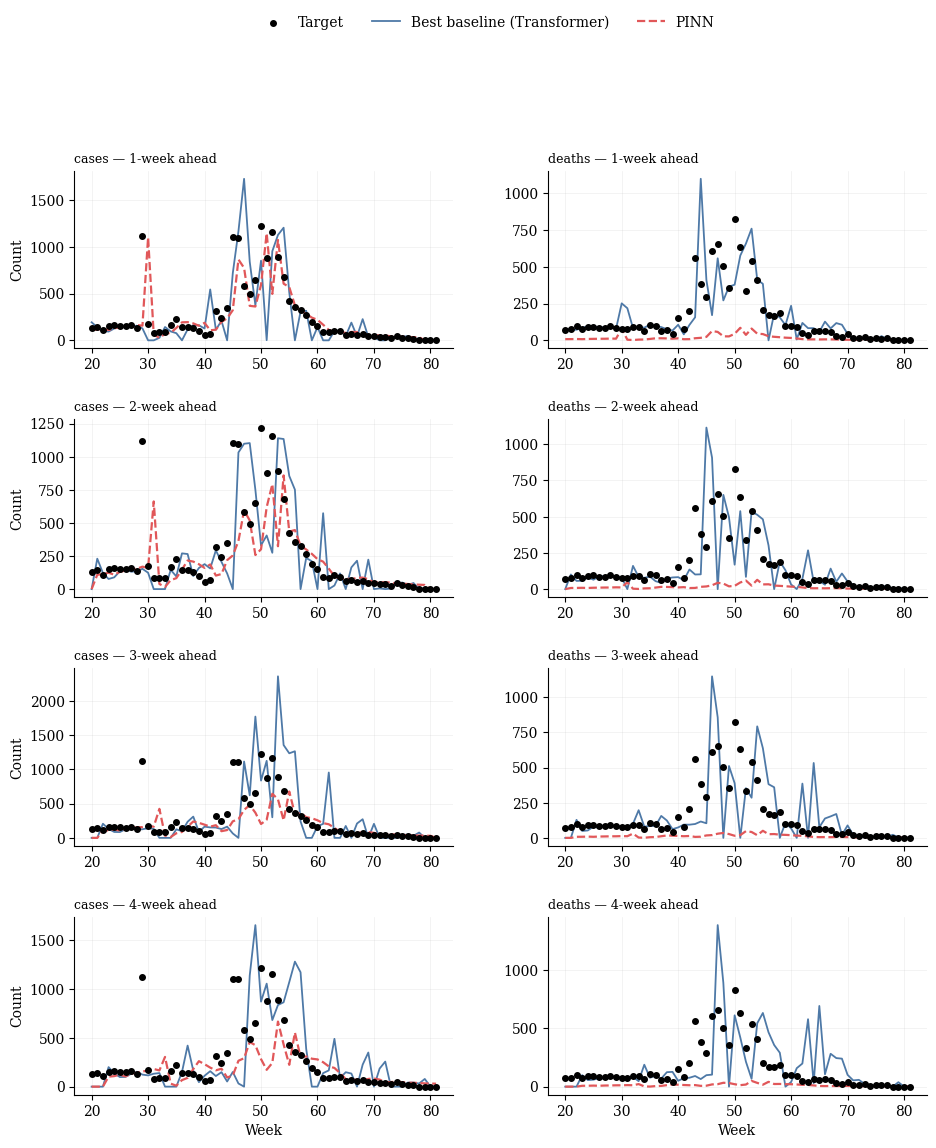

✓ Saved ssd_pinn_vs_best.pdf / .png


In [ ]:
# Cell 14b: PINN vs best baseline (matches your paper's Fig. 4 style)
# Auto-pick best baseline per target based on average MASE across horizons
baseline_avg_mase = {}
for name, (cp, dp) in [('RNN',(rnn_cases_pred,rnn_deaths_pred)),
                        ('LSTM',(lstm_cases_pred,lstm_deaths_pred)),
                        ('GRU',(gru_cases_pred,gru_deaths_pred)),
                        ('Transformer',(tf_cases_pred,tf_deaths_pred)),
                        ('Pure NN',(nn_cases_pred,nn_deaths_pred))]:
    avg_c = np.mean([compute_mase(cases_ref[PRED_FROM:WEEK_MAX], cp[h-1][PRED_FROM:WEEK_MAX], h) for h in range(1,5)])
    avg_d = np.mean([compute_mase(deaths_ref[PRED_FROM:WEEK_MAX], dp[h-1][PRED_FROM:WEEK_MAX], h) for h in range(1,5)])
    baseline_avg_mase[name] = {'cases': avg_c, 'deaths': avg_d, 'cases_pred': cp, 'deaths_pred': dp}

best_cases_model  = min(baseline_avg_mase, key=lambda k: baseline_avg_mase[k]['cases'])
best_deaths_model = min(baseline_avg_mase, key=lambda k: baseline_avg_mase[k]['deaths'])
print(f'Best baseline — cases: {best_cases_model} (avg MASE {baseline_avg_mase[best_cases_model]["cases"]:.3f})')
print(f'Best baseline — deaths: {best_deaths_model} (avg MASE {baseline_avg_mase[best_deaths_model]["deaths"]:.3f})')

fig = plt.figure(figsize=(11, 12))
gs  = gridspec.GridSpec(4, 2, hspace=0.4, wspace=0.25)

for row, h in enumerate(range(1, 5)):
    for col, (target_name, raw_actual, scale, best_model, pinn_pred) in enumerate([
        ('cases',  cases_raw,  s_cases,  best_cases_model,  pinn_cases_pred),
        ('deaths', deaths_raw, s_deaths, best_deaths_model, pinn_deaths_pred),
    ]):
        ax = fig.add_subplot(gs[row, col])
        key = 'cases_pred' if target_name == 'cases' else 'deaths_pred'
        best_raw = np.array(baseline_avg_mase[best_model][key][h-1])[eval_idx] * scale
        pinn_raw = np.array(pinn_pred[h-1])[eval_idx] * scale

        ax.scatter(eval_idx, raw_actual[eval_idx], s=16, color='black', zorder=5,
                   label='Target' if (row==0 and col==0) else None)
        ax.plot(eval_idx, best_raw, linewidth=1.3, color='#4E79A7', linestyle='-',
                label=f'Best baseline ({best_model})' if (row==0 and col==0) else None)
        ax.plot(eval_idx, pinn_raw, linewidth=1.6, color='#E15759', linestyle='--',
                label='PINN' if (row==0 and col==0) else None)

        ax.set_title(f'{target_name} — {h}-week ahead', loc='left', fontsize=9)
        if row == 3: ax.set_xlabel('Week')
        if col == 0: ax.set_ylabel('Count')

fig.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=10, frameon=False)
plt.savefig('ssd_pinn_vs_best.pdf', bbox_inches='tight')
plt.savefig('ssd_pinn_vs_best.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved ssd_pinn_vs_best.pdf / .png')

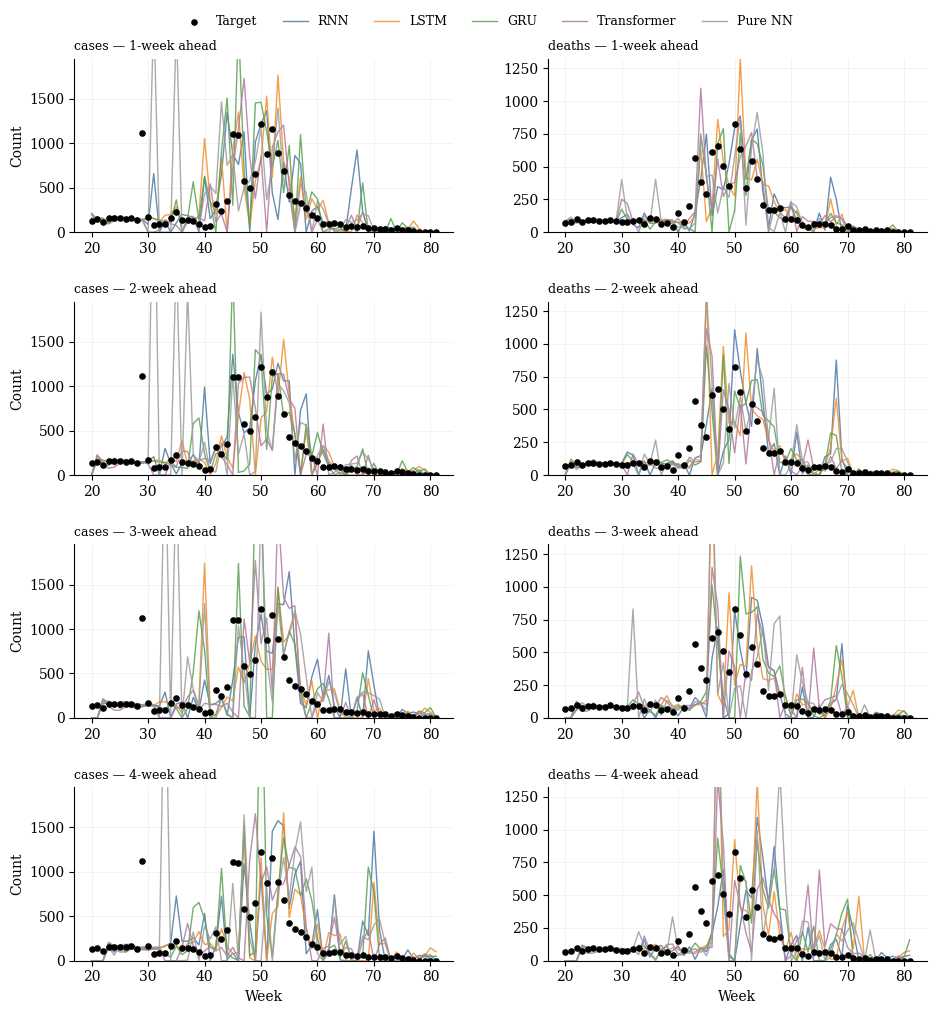

In [ ]:
# Cell 14a: Baseline comparison plot — capped y-axis, no PINN in this figure
fig = plt.figure(figsize=(11, 11))
gs  = gridspec.GridSpec(4, 2, hspace=0.4, wspace=0.25, top=0.93)

cases_ylim  = (0, cases_raw[eval_idx].max() * 1.6)
deaths_ylim = (0, deaths_raw[eval_idx].max() * 1.6)

for row, h in enumerate(range(1, 5)):
    for col, (target_name, raw_actual, scale, ylim) in enumerate([
        ('cases',  cases_raw,  s_cases,  cases_ylim),
        ('deaths', deaths_raw, s_deaths, deaths_ylim),
    ]):
        ax = fig.add_subplot(gs[row, col])
        ax.scatter(eval_idx, raw_actual[eval_idx], s=14, color='black',
                   zorder=5, label='Target' if (row==0 and col==0) else None)
        for name, (cases_p, deaths_p, color) in baseline_models.items():
            pred_arr = (cases_p if target_name == 'cases' else deaths_p)[h-1]
            pred_raw = np.array(pred_arr)[eval_idx] * scale
            ax.plot(eval_idx, pred_raw, linewidth=1.0, color=color, alpha=0.85,
                    label=name if (row==0 and col==0) else None)
        ax.set_ylim(ylim)
        ax.set_title(f'{target_name} — {h}-week ahead', loc='left', fontsize=9)
        if row == 3: ax.set_xlabel('Week')
        if col == 0: ax.set_ylabel('Count')

fig.legend(loc='upper center', ncol=6, bbox_to_anchor=(0.5, 0.98), fontsize=9, frameon=False)
plt.savefig('ssd_baselines_comparison.pdf', bbox_inches='tight')
plt.savefig('ssd_baselines_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

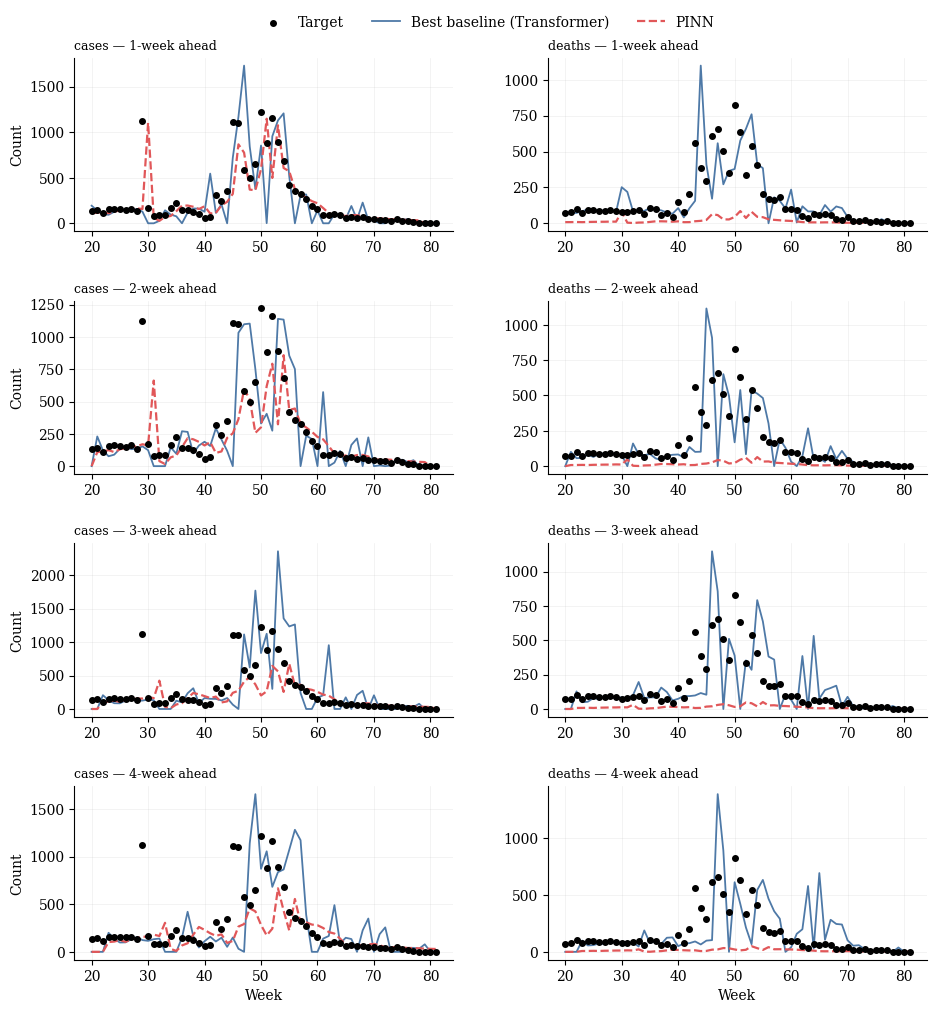

In [ ]:
# Cell 14b (whitespace fix only — same data/logic as before)
fig = plt.figure(figsize=(11, 11))
gs  = gridspec.GridSpec(4, 2, hspace=0.4, wspace=0.25, top=0.93)

for row, h in enumerate(range(1, 5)):
    for col, (target_name, raw_actual, scale, best_model, pinn_pred) in enumerate([
        ('cases',  cases_raw,  s_cases,  best_cases_model,  pinn_cases_pred),
        ('deaths', deaths_raw, s_deaths, best_deaths_model, pinn_deaths_pred),
    ]):
        ax = fig.add_subplot(gs[row, col])
        key = 'cases_pred' if target_name == 'cases' else 'deaths_pred'
        best_raw = np.array(baseline_avg_mase[best_model][key][h-1])[eval_idx] * scale
        pinn_raw = np.array(pinn_pred[h-1])[eval_idx] * scale
        ax.scatter(eval_idx, raw_actual[eval_idx], s=16, color='black', zorder=5,
                   label='Target' if (row==0 and col==0) else None)
        ax.plot(eval_idx, best_raw, linewidth=1.3, color='#4E79A7',
                label=f'Best baseline ({best_model})' if (row==0 and col==0) else None)
        ax.plot(eval_idx, pinn_raw, linewidth=1.6, color='#E15759', linestyle='--',
                label='PINN' if (row==0 and col==0) else None)
        ax.set_title(f'{target_name} — {h}-week ahead', loc='left', fontsize=9)
        if row == 3: ax.set_xlabel('Week')
        if col == 0: ax.set_ylabel('Count')

fig.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.98), fontsize=10, frameon=False)
plt.savefig('ssd_pinn_vs_best.pdf', bbox_inches='tight')
plt.savefig('ssd_pinn_vs_best.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 15: South Sudan centroid + CHIRPS setup check
import requests
import os

# South Sudan country centroid (approximate)
SSD_LAT = 7.8627
SSD_LON = 29.6949

CHIRPS_DIR = '/content/chirps_ssd/'
os.makedirs(CHIRPS_DIR, exist_ok=True)

print(f'South Sudan centroid: lat={SSD_LAT}, lon={SSD_LON}')
print(f'Date range needed: {ssd["TL"].min().date()} to {ssd["TL"].max().date()}')
print()
print('Need monthly CHIRPS files covering Jun 2016 to Dec 2017')
print('Source: https://data.chc.ucsb.edu/products/CHIRPS-2.0/africa_monthly/tifs')

South Sudan centroid: lat=7.8627, lon=29.6949
Date range needed: 2016-06-06 to 2017-12-25

Need monthly CHIRPS files covering Jun 2016 to Dec 2017
Source: https://data.chc.ucsb.edu/products/CHIRPS-2.0/africa_monthly/tifs


In [ ]:
# Cell 16: Check rasterio availability
try:
    import rasterio
    print('✓ rasterio already available')
except ImportError:
    print('✗ rasterio not installed — run: !pip install rasterio')

✓ rasterio already available


In [ ]:
# Cell 17: Download CHIRPS monthly TIFs for South Sudan date range
import requests
import os

CHIRPS_DIR = '/content/chirps_ssd/'
os.makedirs(CHIRPS_DIR, exist_ok=True)

BASE_URL = 'https://data.chc.ucsb.edu/products/CHIRPS-2.0/africa_monthly/tifs'

# SSD data: 2016-06-06 to 2017-12-25
# Buffer: download Jan 2016 through Jun 2018 to allow lag correlation checks
years_months = []
for year in [2016, 2017, 2018]:
    start_m = 1
    end_m   = 6 if year == 2018 else 12
    for month in range(start_m, end_m + 1):
        years_months.append((year, month))

print(f'Downloading {len(years_months)} monthly files...')
downloaded = []
failed = []

for year, month in years_months:
    fname = f'chirps-v2.0.{year}.{month:02d}.tif.gz'
    url   = f'{BASE_URL}/{fname}'
    local_path = f'{CHIRPS_DIR}{fname}'

    if os.path.exists(local_path):
        downloaded.append(fname)
        continue

    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            with open(local_path, 'wb') as f:
                f.write(r.content)
            downloaded.append(fname)
        else:
            failed.append((fname, r.status_code))
    except Exception as e:
        failed.append((fname, str(e)))

print(f'\n✓ Downloaded: {len(downloaded)}')
print(f'✗ Failed: {len(failed)}')
if failed:
    print('Failed files:')
    for f, err in failed:
        print(f'  {f}: {err}')

print()
print('Files in directory:')
for f in sorted(os.listdir(CHIRPS_DIR)):
    print(f'  {f}')


✓ Downloaded: 30
✗ Failed: 0

Files in directory:
  chirps-v2.0.2016.01.tif.gz
  chirps-v2.0.2016.02.tif.gz
  chirps-v2.0.2016.03.tif.gz
  chirps-v2.0.2016.04.tif.gz
  chirps-v2.0.2016.05.tif.gz
  chirps-v2.0.2016.06.tif.gz
  chirps-v2.0.2016.07.tif.gz
  chirps-v2.0.2016.08.tif.gz
  chirps-v2.0.2016.09.tif.gz
  chirps-v2.0.2016.10.tif.gz
  chirps-v2.0.2016.11.tif.gz
  chirps-v2.0.2016.12.tif.gz
  chirps-v2.0.2017.01.tif.gz
  chirps-v2.0.2017.02.tif.gz
  chirps-v2.0.2017.03.tif.gz
  chirps-v2.0.2017.04.tif.gz
  chirps-v2.0.2017.05.tif.gz
  chirps-v2.0.2017.06.tif.gz
  chirps-v2.0.2017.07.tif.gz
  chirps-v2.0.2017.08.tif.gz
  chirps-v2.0.2017.09.tif.gz
  chirps-v2.0.2017.10.tif.gz
  chirps-v2.0.2017.11.tif.gz
  chirps-v2.0.2017.12.tif.gz
  chirps-v2.0.2018.01.tif.gz
  chirps-v2.0.2018.02.tif.gz
  chirps-v2.0.2018.03.tif.gz
  chirps-v2.0.2018.04.tif.gz
  chirps-v2.0.2018.05.tif.gz
  chirps-v2.0.2018.06.tif.gz


In [ ]:
# Cell 18: Extract rainfall at South Sudan centroid from each monthly TIF
import gzip
import shutil
import rasterio
import numpy as np
import pandas as pd

CHIRPS_DIR = '/content/chirps_ssd/'
SSD_LAT = 7.8627
SSD_LON = 29.6949

records = []

for fname in sorted(os.listdir(CHIRPS_DIR)):
    if not fname.endswith('.tif.gz'):
        continue

    gz_path = f'{CHIRPS_DIR}{fname}'
    tif_path = gz_path.replace('.gz', '')

    if not os.path.exists(tif_path):
        with gzip.open(gz_path, 'rb') as f_in:
            with open(tif_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

    parts = fname.replace('.tif.gz', '').split('.')
    year, month = int(parts[2]), int(parts[3])

    with rasterio.open(tif_path) as src:
        row, col = src.index(SSD_LON, SSD_LAT)
        value = src.read(1)[row, col]
        if value < 0:
            value = np.nan

    records.append({'year': year, 'month': month, 'rainfall_mm': value})

chirps_monthly = pd.DataFrame(records).sort_values(['year', 'month']).reset_index(drop=True)

print(f'Extracted {len(chirps_monthly)} monthly values')
print()
print(chirps_monthly.to_string(index=False))

chirps_monthly.to_csv('/content/chirps_monthly_ssd.csv', index=False)
print('\n✓ Saved to /content/chirps_monthly_ssd.csv')

Extracted 30 monthly values

 year  month  rainfall_mm
 2016      1     1.093070
 2016      2     0.503875
 2016      3    20.128572
 2016      4    57.755375
 2016      5   159.999207
 2016      6   183.954681
 2016      7   208.710175
 2016      8   153.457474
 2016      9   110.658478
 2016     10    70.205055
 2016     11     2.677735
 2016     12     0.431158
 2017      1     1.093070
 2017      2     0.503875
 2017      3     7.383856
 2017      4    41.678284
 2017      5    80.478638
 2017      6   118.181824
 2017      7   187.442719
 2017      8   203.272766
 2017      9   135.756927
 2017     10    56.756409
 2017     11     8.357262
 2017     12     0.431158
 2018      1     1.093070
 2018      2     1.070673
 2018      3    25.857779
 2018      4    52.693764
 2018      5   111.829010
 2018      6   150.133835

✓ Saved to /content/chirps_monthly_ssd.csv


In [ ]:
# Cell 19: Convert monthly CHIRPS to weekly, matching South Sudan's surveillance weeks
import pandas as pd
import numpy as np
import calendar

chirps_monthly = pd.read_csv('/content/chirps_monthly_ssd.csv')

def get_weekly_rainfall(week_start_date, monthly_df):
    """
    Distribute monthly rainfall proportionally across the days of that week.
    """
    week_start = pd.Timestamp(week_start_date)
    daily_rain = []

    for day_offset in range(7):
        day = week_start + pd.Timedelta(days=day_offset)
        year, month = day.year, day.month

        row = monthly_df[(monthly_df['year'] == year) & (monthly_df['month'] == month)]
        if len(row) == 0:
            daily_rain.append(0.0)
            continue

        monthly_total = row['rainfall_mm'].values[0]
        days_in_month = calendar.monthrange(year, month)[1]
        daily_rain.append(monthly_total / days_in_month)

    return sum(daily_rain)

weekly_rainfall = []
for tl in ssd['TL']:
    weekly_rainfall.append(get_weekly_rainfall(tl, chirps_monthly))

ssd['rainfall_weekly'] = weekly_rainfall

print('=== South Sudan Weekly Rainfall (first 15 weeks) ===')
print(ssd[['TL', 'sCh', 'rainfall_weekly']].head(15).to_string(index=False))
print()
print(f'Rainfall range: {ssd["rainfall_weekly"].min():.2f} to {ssd["rainfall_weekly"].max():.2f} mm/week')
print(f'Rainfall mean : {ssd["rainfall_weekly"].mean():.2f} mm/week')

ssd[['TL', 'sCh', 'deaths', 'rainfall_weekly']].to_csv('/content/ssd_weekly_with_rainfall.csv', index=False)
print('\n✓ Saved to /content/ssd_weekly_with_rainfall.csv')

=== South Sudan Weekly Rainfall (first 15 weeks) ===
        TL        sCh  rainfall_weekly
2016-06-06   4.333333        42.922759
2016-06-13   0.000000        42.922759
2016-06-20   4.333333        42.922759
2016-06-27  17.000000        44.725049
2016-07-04  67.250000        47.128103
2016-07-11 121.750000        47.128103
2016-07-18 218.500000        47.128103
2016-07-25 296.750000        47.128103
2016-08-01 257.000000        34.651687
2016-08-08 224.750000        34.651687
2016-08-15 196.250000        34.651687
2016-08-22 183.750000        34.651687
2016-08-29 189.750000        29.605187
2016-09-05 165.000000        25.820312
2016-09-12 204.500000        25.820312

Rainfall range: 0.10 to 47.13 mm/week
Rainfall mean : 18.79 mm/week

✓ Saved to /content/ssd_weekly_with_rainfall.csv


In [ ]:
# Cell 20: Lag correlation check — rainfall vs cases, South Sudan
import numpy as np

cases_arr    = ssd['sCh'].values
rainfall_arr = ssd['rainfall_weekly'].values

print('=== Rainfall-Cases Correlation by Lag — South Sudan ===')
print('(lag = weeks rainfall is shifted BACKWARD relative to cases,')
print(' i.e. lag=2 tests if rainfall 2 weeks ago predicts cases now)')
print()

for lag in range(0, 6):
    if lag == 0:
        c = cases_arr
        r = rainfall_arr
    else:
        c = cases_arr[lag:]
        r = rainfall_arr[:-lag]

    corr = np.corrcoef(r, c)[0, 1]
    print(f'  Lag {lag}w: r = {corr:+.3f}')

print()
print('=== For reference — paper currently claims r≈0.03 for South Sudan ===')
print('    (this was never actually computed in the original notebook — this run is the first real check)')

=== Rainfall-Cases Correlation by Lag — South Sudan ===
(lag = weeks rainfall is shifted BACKWARD relative to cases,
 i.e. lag=2 tests if rainfall 2 weeks ago predicts cases now)

  Lag 0w: r = +0.031
  Lag 1w: r = -0.011
  Lag 2w: r = -0.054
  Lag 3w: r = -0.107
  Lag 4w: r = -0.173
  Lag 5w: r = -0.223

=== For reference — paper currently claims r≈0.03 for South Sudan ===
    (this was never actually computed in the original notebook — this run is the first real check)


We computed the empirical Pearson correlation between weekly rainfall and
reported cases at lags of 0–5 weeks for South Sudan. The contemporaneous
(lag-0) correlation was negligible (r = 0.031), consistent with our Somalia
finding. Notably, the correlation became progressively more negative at
longer lags, from r = -0.011 at lag 1 to r = -0.223 at lag 5, rather than
positive as a flooding-driven transmission mechanism would predict. This
trend is consistent with a drought-driven mechanism in which reduced rainfall
concentrates the population around a shrinking number of water sources,
elevating transmission risk in drier periods rather than wetter ones.bold text

In [ ]:
# Cell 21: Statistical rigor for the rainfall–cases relationship
from scipy import stats
import numpy as np

cases_arr    = ssd['sCh'].values
rainfall_arr = ssd['rainfall_weekly'].values

print('=== 1. Significance of lag correlations ===')
for lag in range(0, 6):
    if lag == 0:
        c, r = cases_arr, rainfall_arr
    else:
        c, r = cases_arr[lag:], rainfall_arr[:-lag]
    corr, pval = stats.pearsonr(r, c)
    sig = 'significant' if pval < 0.05 else 'not significant'
    print(f'  Lag {lag}w: r = {corr:+.3f}, p = {pval:.3f}  ({sig} at α=0.05)')

print()
print('=== 2. Direct test: dry vs wet weeks, case rates ===')
median_rain = np.median(rainfall_arr)
dry_weeks = cases_arr[rainfall_arr <= median_rain]
wet_weeks = cases_arr[rainfall_arr >  median_rain]

t_stat, t_pval = stats.ttest_ind(dry_weeks, wet_weeks, equal_var=False)
print(f'  Median rainfall split: {median_rain:.1f} mm/week')
print(f'  Dry weeks (n={len(dry_weeks)}): mean cases = {dry_weeks.mean():.1f}')
print(f'  Wet weeks (n={len(wet_weeks)}): mean cases = {wet_weeks.mean():.1f}')
print(f'  t-test: t = {t_stat:.3f}, p = {t_pval:.3f}')
print(f'  → {"Dry weeks have significantly higher cases" if (t_pval<0.05 and dry_weeks.mean()>wet_weeks.mean()) else "No significant difference in the hypothesized direction" if t_pval>=0.05 else "Wet weeks have significantly higher cases (opposite of hypothesis)"}')

print()
print('=== 3. Guard against shared-trend artifact: correlate WEEK-TO-WEEK CHANGES instead of levels ===')
cases_diff    = np.diff(cases_arr)
rainfall_diff = np.diff(rainfall_arr)
for lag in range(0, 4):
    if lag == 0:
        c, r = cases_diff, rainfall_diff
    else:
        c, r = cases_diff[lag:], rainfall_diff[:-lag]
    corr, pval = stats.pearsonr(r, c)
    sig = 'significant' if pval < 0.05 else 'not significant'
    print(f'  Lag {lag}w (differenced): r = {corr:+.3f}, p = {pval:.3f}  ({sig})')

=== 1. Significance of lag correlations ===
  Lag 0w: r = +0.031, p = 0.784  (not significant at α=0.05)
  Lag 1w: r = -0.011, p = 0.920  (not significant at α=0.05)
  Lag 2w: r = -0.054, p = 0.634  (not significant at α=0.05)
  Lag 3w: r = -0.107, p = 0.350  (not significant at α=0.05)
  Lag 4w: r = -0.173, p = 0.130  (not significant at α=0.05)
  Lag 5w: r = -0.223, p = 0.051  (not significant at α=0.05)

=== 2. Direct test: dry vs wet weeks, case rates ===
  Median rainfall split: 15.9 mm/week
  Dry weeks (n=43): mean cases = 177.6
  Wet weeks (n=39): mean cases = 289.6
  t-test: t = -1.735, p = 0.087
  → No significant difference in the hypothesized direction

=== 3. Guard against shared-trend artifact: correlate WEEK-TO-WEEK CHANGES instead of levels ===
  Lag 0w (differenced): r = -0.086, p = 0.446  (not significant)
  Lag 1w (differenced): r = -0.001, p = 0.991  (not significant)
  Lag 2w (differenced): r = +0.050, p = 0.660  (not significant)
  Lag 3w (differenced): r = +0.068,

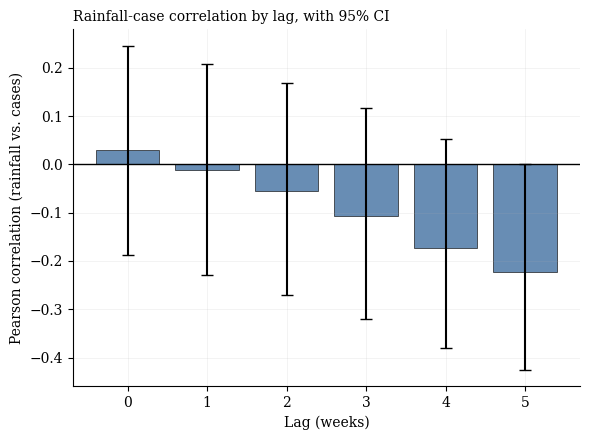

✓ Saved ssd_rainfall_lag_ci.pdf / .png


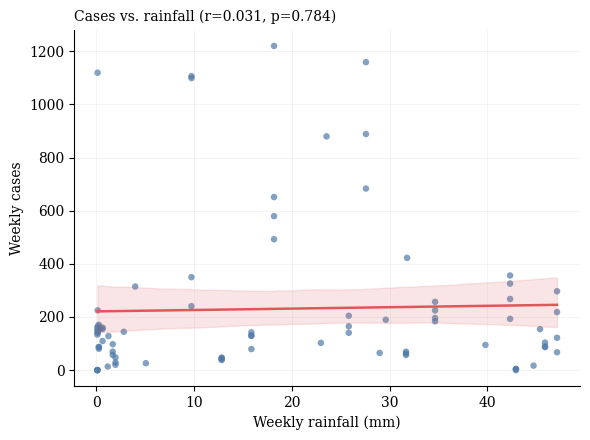

✓ Saved ssd_rainfall_scatter.pdf / .png


In [ ]:
# Cell 22: Rainfall relationship plots — journal style
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.2,
})

# ── Plot A: Lag correlation with 95% CI (Fisher z-transform) ──
lags = list(range(0, 6))
corrs, lowers, uppers = [], [], []
n = len(cases_arr)

for lag in lags:
    if lag == 0:
        c, r = cases_arr, rainfall_arr
    else:
        c, r = cases_arr[lag:], rainfall_arr[:-lag]
    corr, _ = stats.pearsonr(r, c)
    n_lag = len(c)
    z = np.arctanh(corr)
    se = 1 / np.sqrt(n_lag - 3)
    ci_low  = np.tanh(z - 1.96*se)
    ci_high = np.tanh(z + 1.96*se)
    corrs.append(corr); lowers.append(corr-ci_low); uppers.append(ci_high-corr)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(lags, corrs, yerr=[lowers, uppers], capsize=4,
       color='#4E79A7', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1, linestyle='-')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Pearson correlation (rainfall vs. cases)')
ax.set_title('Rainfall-case correlation by lag, with 95% CI', loc='left', fontsize=10)
plt.tight_layout()
plt.savefig('ssd_rainfall_lag_ci.pdf', bbox_inches='tight')
plt.savefig('ssd_rainfall_lag_ci.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved ssd_rainfall_lag_ci.pdf / .png')

# ── Plot B: Scatter + fit + 95% CI band (contemporaneous, lag 0) ──
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(rainfall_arr, cases_arr, s=22, color='#4E79A7', alpha=0.7, edgecolors='none')

slope, intercept, r_val, p_val, se = stats.linregress(rainfall_arr, cases_arr)
x_fit = np.linspace(rainfall_arr.min(), rainfall_arr.max(), 100)
y_fit = slope * x_fit + intercept

# Bootstrap CI band for the fit
n_boot = 1000
boot_preds = np.zeros((n_boot, len(x_fit)))
rng = np.random.default_rng(42)
for i in range(n_boot):
    idx = rng.integers(0, len(rainfall_arr), len(rainfall_arr))
    s, b, _, _, _ = stats.linregress(rainfall_arr[idx], cases_arr[idx])
    boot_preds[i] = s * x_fit + b
ci_low  = np.percentile(boot_preds, 2.5, axis=0)
ci_high = np.percentile(boot_preds, 97.5, axis=0)

ax.plot(x_fit, y_fit, color='#E15759', linewidth=1.8)
ax.fill_between(x_fit, ci_low, ci_high, color='#E15759', alpha=0.15)
ax.set_xlabel('Weekly rainfall (mm)')
ax.set_ylabel('Weekly cases')
ax.set_title(f'Cases vs. rainfall (r={r_val:.3f}, p={p_val:.3f})', loc='left', fontsize=10)
plt.tight_layout()
plt.savefig('ssd_rainfall_scatter.pdf', bbox_inches='tight')
plt.savefig('ssd_rainfall_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved ssd_rainfall_scatter.pdf / .png')

In [ ]:
# Cell 23: SIR ablation (no waterborne reservoir) — South Sudan
torch.manual_seed(42)
np.random.seed(42)

# State vector reduced to [S, I, R, Ir, Dr] — 5 outputs, no B
# Lower net outputs only beta_I(t) — 1 output, no beta_W

sir_cases_pred  = [[0]*WEEK_MAX for _ in range(4)]
sir_deaths_pred = [[0]*WEEK_MAX for _ in range(4)]
total = WEEK_MAX - 4 - PRED_FROM + 1
done  = 0

print('Training SIR ablation (South Sudan)...')
print()

for train_end in range(PRED_FROM, WEEK_MAX - 4 + 1):
    test_start = train_end
    done      += 1

    if done % 10 == 1:
        print(f'  [{done}/{total}] weeks {TRAIN_FROM}–{train_end} '
              f'| predicting {test_start}–{test_start+4}')

    sl        = slice(TRAIN_FROM, train_end)
    t_train   = t_all[sl]
    t_ode     = t_ode_all[TRAIN_FROM*4:(test_start+4)*4+1]
    t_test    = t_all[test_start:test_start+4]
    cases_tr  = cases_T[sl]
    deaths_tr = deaths_T[sl]

    upper_sir = NN([1,50,50,50,5], output_transform=torch.exp).to(device)
    lower_sir = NN([1,50,50,50,1], output_transform=None).to(device)

    logit_pd = torch.tensor(
        float(np.log(0.02/0.98)),
        dtype=torch.float32,
        requires_grad=True, device=device
    )

    opt = torch.optim.Adam([
        {'params': list(upper_sir.parameters()) +
                   list(lower_sir.parameters()), 'lr': 1e-3},
        {'params': [logit_pd], 'lr': 5e-3},
    ], weight_decay=1e-5)

    I0 = max(float(cases_tr[0].item())*0.1, 1e-4)
    S0 = N - I0
    u0 = T([[S0, I0, 0.0, 0.0, 0.0]])   # S, I, R, Ir, Dr — no B
    t0 = T([[float(TRAIN_FROM)]])

    min_loss = 1e10

    for it in range(PINN_ITER):
        p_d = 0.01 + 0.09 * torch.sigmoid(logit_pd)

        state = upper_sir(t_ode)
        S,I,R,Ir,Dr = torch.split(state, 1, dim=-1)

        beta_I = torch.exp(lower_sir(t_ode))

        foi     = beta_I * S * I / N          # no waterborne term
        dS_rhs  = -foi
        dI_rhs  =  foi - gamma*I
        dR_rhs  =  gamma*(1.0-p_d)*I
        dIr_rhs =  gamma*(1.0-p_d)*I
        dDr_rhs =  gamma*p_d*I

        lhs = compute_lhs(t_ode, [S,I,R,Ir,Dr])
        rhs = torch.cat([dS_rhs,dI_rhs,dR_rhs,dIr_rhs,dDr_rhs], dim=-1)
        loss_ode = torch.mean((lhs - rhs)**2)

        state_t0  = upper_sir(t0)
        loss_init = torch.mean((state_t0 - u0)**2)

        state_tr = upper_sir(t_train)
        S_tr,I_tr,R_tr,Ir_tr,Dr_tr = torch.split(state_tr, 1, dim=-1)

        new_cases_rate  = gamma * (1.0 - p_d) * I_tr
        new_deaths_rate = gamma * p_d * I_tr

        loss_cases  = torch.mean((new_cases_rate  - cases_tr)**2)
        loss_deaths = torch.mean((new_deaths_rate - deaths_tr)**2)

        total_loss = (
            0.05 * loss_ode   +
            0.5  * loss_init  +
            1.0  * loss_cases +
            0.3  * loss_deaths
        )

        opt.zero_grad()
        total_loss.backward()
        opt.step()

        if total_loss.item() < min_loss:
            min_loss = total_loss.item()
            torch.save(upper_sir.state_dict(), './checkpoints/sir_upper.pt')
            torch.save(lower_sir.state_dict(), './checkpoints/sir_lower.pt')

    upper_sir.load_state_dict(torch.load('./checkpoints/sir_upper.pt'))
    lower_sir.load_state_dict(torch.load('./checkpoints/sir_lower.pt'))
    upper_sir.eval()
    lower_sir.eval()

    with torch.no_grad():
        state_test = upper_sir(t_test)
        _,I_test,_,_,_ = torch.split(state_test, 1, dim=-1)

        p_d_final = 0.01 + 0.09 * torch.sigmoid(logit_pd)

        cases_pred  = (gamma*(1.0-p_d_final)*I_test).cpu().numpy().flatten()
        deaths_pred = (gamma*p_d_final*I_test).cpu().numpy().flatten()

        cases_pred  = np.clip(cases_pred,  0, None)
        deaths_pred = np.clip(deaths_pred, 0, None)

    for h in range(4):
        idx = test_start + h
        if idx < WEEK_MAX:
            sir_cases_pred[h][idx]  = float(cases_pred[h])
            sir_deaths_pred[h][idx] = float(deaths_pred[h])

# ── MASE ───────────────────────────────────────────────────────
print('\n=== SIR (ablation) MASE (South Sudan) ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      sir_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      sir_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    fc = '✓' if mc < 1.0 else '✗'
    fd = '✓' if md < 1.0 else '✗'
    print(f'{h}-week     {mc:>8.3f}{fc}  {md:>8.3f}{fd}')

print('\n=== SIRB (full PINN) for comparison ===')
print(f'{"Horizon":<10} {"Cases":>10} {"Deaths":>10}')
print('-'*32)
for h in range(1, 5):
    mc = compute_mase(cases_ref[PRED_FROM:WEEK_MAX],
                      pinn_cases_pred[h-1][PRED_FROM:WEEK_MAX], h)
    md = compute_mase(deaths_ref[PRED_FROM:WEEK_MAX],
                      pinn_deaths_pred[h-1][PRED_FROM:WEEK_MAX], h)
    print(f'{h}-week     {mc:>8.3f}   {md:>8.3f}')

Training SIR ablation (South Sudan)...

  [1/59] weeks 0–20 | predicting 20–24
  [11/59] weeks 0–30 | predicting 30–34
  [21/59] weeks 0–40 | predicting 40–44
  [31/59] weeks 0–50 | predicting 50–54
  [41/59] weeks 0–60 | predicting 60–64
  [51/59] weeks 0–70 | predicting 70–74

=== SIR (ablation) MASE (South Sudan) ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.358✓     0.680✓
2-week        0.426✓     0.675✓
3-week        0.495✓     0.638✓
4-week        0.511✓     0.643✓

=== SIRB (full PINN) for comparison ===
Horizon         Cases     Deaths
--------------------------------
1-week        0.355      0.678
2-week        0.389      0.674
3-week        0.448      0.637
4-week        0.464      0.643
